# XGBoost Modeling

Train and evaluate a XGBoost classifier to predict nucleotide changes in DENV genome regions (E, 5′UTR, 3′UTR) using environmental data (temperature, CO₂), as part of a comparative study for climate-aware viral evolution forecasting.

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)

import joblib

### Load processed data

In [2]:
df = pd.read_csv('../data/processed_genomic_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (359, 2017)


,Avg_Temp_C,CO2_Emission_Mt,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,...,p_2006,p_2007,p_2008,p_2009,p_2010,p_2011,p_2012,p_2013,p_2014,p_2015
0,26.16,2489.9,4,4,3,1,4,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
2,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
3,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
4,26.16,2489.9,4,3,2,3,3,1,4,4,...,0,0,0,0,0,0,0,0,0,0


### Define features and targets (X & y)

In [3]:
feature_cols = df.columns[:2]        
target_cols = df.columns[2:]         

X = df[feature_cols]
y = df[target_cols]

print("Shape of X (features):", X.shape)
print("Shape of y (targets):", y.shape)

Shape of X (features): (359, 2)
Shape of y (targets): (359, 2015)


### Train-Test Split

In [4]:
# 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 251
Test set size: 108


In [7]:
# Number of target positions
n_targets = y_train.shape[1]

# Create a dummy DataFrame with all classes for each column
dummy = pd.DataFrame(np.zeros((5, n_targets)), columns=y_train.columns, dtype=int)
for i in range(n_targets):
    dummy.iloc[:, i] = np.arange(5)  # set each column to [0,1,2,3,4]

# Concatenate dummy samples to training data
X_train_xgb = pd.concat([X_train, X_train.iloc[:5, :]], ignore_index=True)
y_train_xgb = pd.concat([y_train, dummy], ignore_index=True)

### XGBoost Model Training
XGBoost, a state-of-the-art gradient boosting framework, was implemented using a multi-output classifier wrapper to enable simultaneous prediction of all 2015 nucleotide positions.

In [8]:
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'  
)

# Multi-output wrapper
xgb_multi = MultiOutputClassifier(xgb_base, n_jobs=-1)

# Fit the Model
xgb_multi.fit(X_train_xgb, y_train_xgb)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=7,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=-1,
                                              num_parallel_tree=None, ...),
                      n_jobs=-1)

**Model Hyperparameter Choices:**

- `n_estimators=100`:  
  Set to 100 boosting rounds to balance model robustness and computational efficiency. A higher number of estimators can improve accuracy by reducing bias, but also increases computation time and risk of overfitting. For this dataset size, 100 estimators is a standard, well-tested value providing reliable performance without excessive resource use.

- `max_depth=7`:  
  Restricted to a maximum tree depth of 7 to prevent overfitting on a relatively small sample size (359 samples). Deeper trees can memorize noise and reduce generalization, while a moderate depth encourages the model to prioritize the most informative splits and patterns in the data.

- `learning_rate=0.1`:  
  Set to 0.1 to provide a balanced step size for each boosting round. Lower learning rates can yield higher accuracy but require more boosting rounds, while higher values may cause the model to converge too quickly and risk missing optimal solutions. The chosen value of 0.1 is commonly used for initial model development and benchmarking.

- `subsample=0.8`:  
  The subsample parameter is set to 0.8 to introduce randomness by sampling 80% of the training data for each boosting round. This regularization technique helps to prevent overfitting and increases model robustness by ensuring diversity among the base learners.

- `colsample_bytree=0.8`:  
  80% of features are randomly selected for each tree, which further reduces overfitting and enhances generalization by promoting diversity among trees in the ensemble.

- `random_state=42`:  
  Fixed to ensure reproducibility of results. Consistent seeding enables fair and comparable evaluation across different modeling approaches.

- `n_jobs=-1`:  
  Utilizes all available CPU cores for parallel computation, significantly accelerating model training and prediction, especially for high-dimensional or multi-output tasks.

- `eval_metric='mlogloss'`:  
  The multi-class log-loss metric is chosen for monitoring convergence during training, as it is well suited for multi-class classification and provides a robust assessment of model calibration.

*As with other models in this study, comprehensive hyperparameter tuning (e.g., grid search or Bayesian optimization) is reserved for future research to maintain computational efficiency and focus on core thesis objectives.*

### Model Evaluation

#### Predict on test set

In [9]:
y_pred = xgb_multi.predict(X_test)

#### Overall accuracy

In [10]:
overall_accuracy = (y_pred == y_test.values).mean()
print(f"Overall nucleotide-level accuracy: {overall_accuracy:.3f}")

Overall nucleotide-level accuracy: 0.449


#### Per-position accuracy

In [11]:
per_position_accuracy = (y_pred == y_test.values).mean(axis=0)
per_position_df = pd.DataFrame({
    'position': target_cols,
    'accuracy': per_position_accuracy
})
print(per_position_df.head())

  position  accuracy
0      p_1  0.574074
1      p_2  0.462963
2      p_3  0.537037
3      p_4  0.620370
4      p_5  0.611111


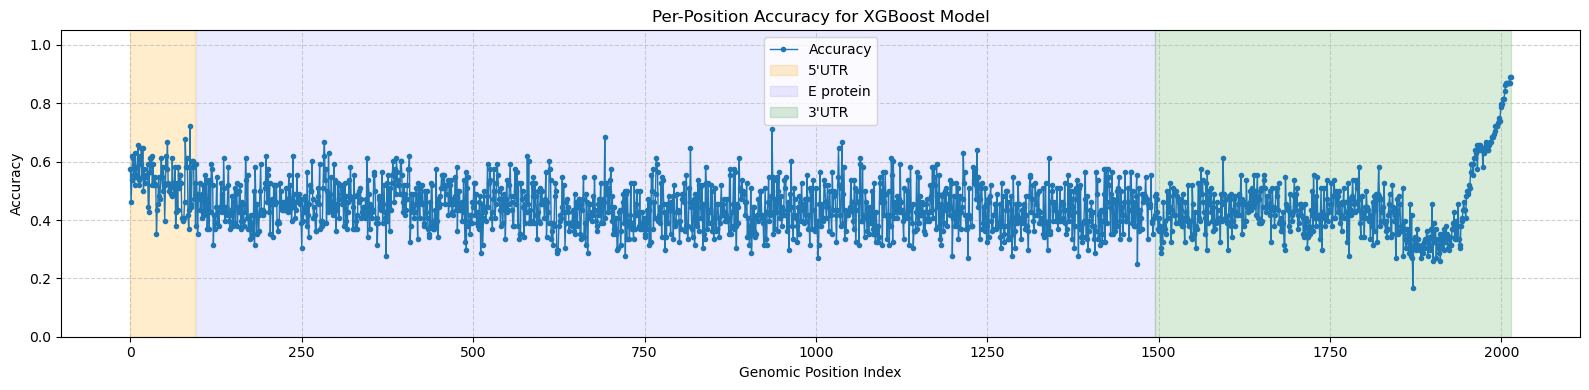

In [12]:
# Plot per-position accuracy with region labels (E, 5′UTR, 3′UTR)
utr5_start, utr5_end = 0, 94       
e_start, e_end = 95, 1494          
utr3_start, utr3_end = 1495, 2014  

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), per_position_accuracy, marker='.', linestyle='-', linewidth=1, label='Accuracy')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per-Position Accuracy for XGBoost Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Accuracy for XGBoost Model

The above plot displays the per-position nucleotide prediction accuracy of the XGBoost model across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. Each data point represents the proportion of correct nucleotide predictions at a specific genomic position in the test set, with colored backgrounds marking the biologically distinct genome segments (5′UTR, E protein, 3′UTR).

#### Key Insights:

- **Overall performance:**  
  The XGBoost model achieves moderate to high accuracy across most positions, with values predominantly ranging between 0.35 and 0.6. This performance is in line with other tree-based ensemble models, indicating strong predictive power when modeling nucleotide variation from environmental variables.

- **5′UTR (orange, left):**  
  The accuracy within the 5′UTR is variable but generally mirrors the patterns observed in the E protein region. No extreme outliers are present, suggesting that environmental variables have some predictive value for these positions, but intrinsic sequence variability limits perfect classification.

- **Envelope (E) protein (blue, center):**  
  Accuracy remains stable across the E protein, with only minor local fluctuations. Occasional dips and spikes likely reflect the underlying biological complexity and evolutionary diversity of this region, where certain nucleotide positions are more difficult to predict from environmental features alone.

- **3′UTR (green, right):**  
  There is a pronounced upward trend in accuracy toward the terminal end of the 3′UTR region, where the model achieves its highest per-position accuracy. This is consistent with regions that are highly conserved or padded, where the prediction task is comparatively easier.

- **Difficult-to-predict positions:**  
  Some positions throughout the sequence show lower accuracy, which may correspond to mutation hotspots, rare nucleotides, or sites where environmental predictors offer limited information.

In [13]:
# Save per-position accuracy
per_position_df.to_csv('../results/xgb_per_position_accuracy.csv', index=False)

#### Calculate per-position Classification Report and Confusion Matrix

In [17]:
report_list = []
conf_matrix_list = []

for idx, col in enumerate(target_cols):
    y_true_col = y_test[col]
    y_pred_col = y_pred[:, idx]
    report = classification_report(y_true_col, y_pred_col, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_col, y_pred_col)

    # Flattened classification report (main averages and support)
    row = {
        'position': col,
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall'],
        'support': report['weighted avg']['support']
    }
    # Per-class F1
    for base in ['0', '1', '2', '3', '4']:  # Adjust base labels as in your data
        if base in report:
            row[f'f1_{base}'] = report[base]['f1-score']
            row[f'precision_{base}'] = report[base]['precision']
            row[f'recall_{base}'] = report[base]['recall']
            row[f'support_{base}'] = report[base]['support']
    report_list.append(row)

    # Confusion matrix as a flattened string (or as a nested list)
    conf_matrix_list.append({
        'position': col,
        'confusion_matrix': cm.tolist()
    })

# Convert lists to DataFrames
report_df = pd.DataFrame(report_list)
conf_matrix_df = pd.DataFrame(conf_matrix_list)

In [18]:
report_df.head()

,position,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,support,f1_1,precision_1,...,recall_3,support_3,f1_4,precision_4,recall_4,support_4,f1_0,precision_0,recall_0,support_0
0,p_1,0.366420,0.364173,0.372552,0.552675,0.535622,0.574074,108.0,0.713178,0.676471,...,0.458333,24.0,0.000000,0.000000,0.000000,5.0,NaN,NaN,NaN,NaN
1,p_2,0.361790,0.372807,0.398496,0.404681,0.393210,0.462963,108.0,0.589474,0.491228,...,0.571429,28.0,0.387097,0.600000,0.285714,21.0,NaN,NaN,NaN,NaN
2,p_3,0.465646,0.548142,0.460262,0.500353,0.517766,0.537037,108.0,0.533333,0.800000,...,0.090909,22.0,0.653061,0.571429,0.761905,42.0,NaN,NaN,NaN,NaN
3,p_4,0.424410,0.477408,0.422502,0.577831,0.571258,0.620370,108.0,0.444444,0.500000,...,0.071429,14.0,0.352941,0.375000,0.333333,18.0,NaN,NaN,NaN,NaN
4,p_5,0.367970,0.451993,0.364510,0.534239,0.529958,0.611111,108.0,0.000000,0.000000,...,0.936508,63.0,0.470588,0.666667,0.363636,11.0,NaN,NaN,NaN,NaN


In [19]:
conf_matrix_df.head()

,position,confusion_matrix
0,p_1,"[[46, 6, 9, 0], [8, 5, 5, 0], [11, 2, 11, 0], ..."
1,p_2,"[[28, 1, 9, 0], [13, 0, 6, 2], [10, 0, 16, 2],..."
2,p_3,"[[4, 3, 0, 3], [0, 20, 3, 11], [1, 9, 2, 10], ..."
3,p_4,"[[6, 6, 0, 3], [4, 54, 2, 1], [0, 7, 1, 6], [2..."
4,p_5,"[[0, 1, 13, 1], [2, 3, 14, 0], [1, 2, 59, 1], ..."


#### Plot Macro F1 from classification report

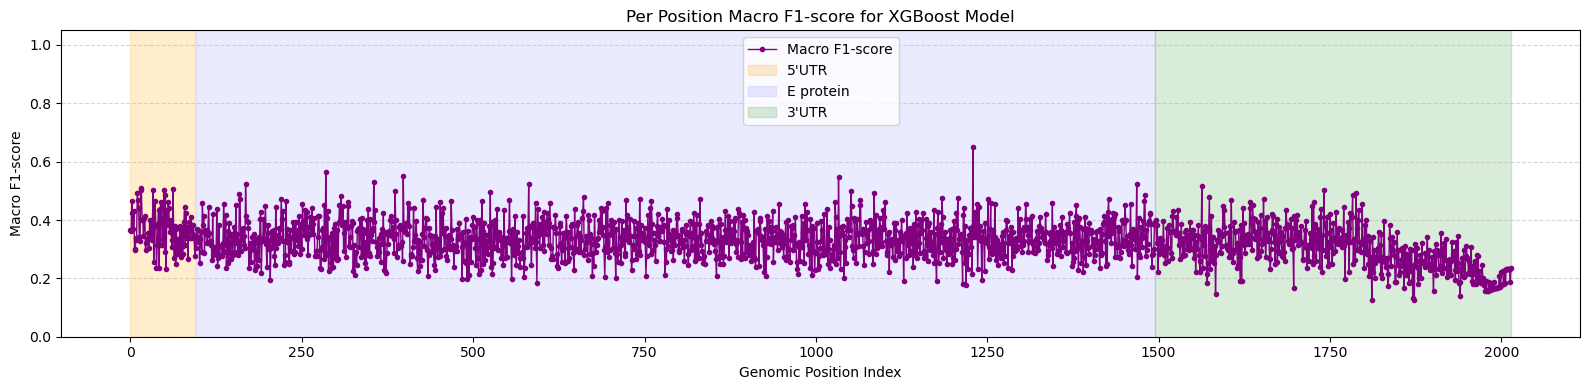

In [21]:
# Extract macro F1 for all positions
positions = report_df['position']
macro_f1 = report_df['macro_f1']

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), macro_f1, marker='.', linestyle='-', linewidth=1, color='purple', label='Macro F1-score')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per Position Macro F1-score for XGBoost Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Macro F1-score')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Macro F1-score for XGBoost Model

The above plot illustrates the macro-averaged F1-score at each nucleotide position for the XGBoost model, evaluated across the 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. The macro F1-score measures the model's balanced predictive performance across all nucleotide classes at each position, accounting for both precision and recall irrespective of class imbalance.

#### Key Insights:

- **Uniformly high F1 performance:**  
  The macro F1-score remains consistently elevated across most genomic positions, with values generally centered around 0.3–0.45. This indicates that XGBoost achieves reliable multi-class classification performance at the nucleotide level, even when distinguishing among rare or imbalanced classes.

- **Regional consistency:**  
  F1-scores remain relatively stable across the 5′UTR, E protein, and 3′UTR, with no drastic drops or spikes except for minor fluctuations, reflecting strong generalizability of the model across functionally distinct regions of the genome.

- **Occasional outliers:**  
  Some positions exhibit localized peaks or drops in F1-score, which may be attributed to specific nucleotide distributions, highly conserved sites, or rare mutation hotspots where the classification task is inherently easier or more difficult.

- **Implications for genomic forecasting:**  
  The robust macro F1-score profile of XGBoost supports its suitability as a state-of-the-art method for genome-wide, environment-informed nucleotide prediction, delivering strong performance even in challenging multi-class settings.

#### Plot Per-Class F1 from classification report

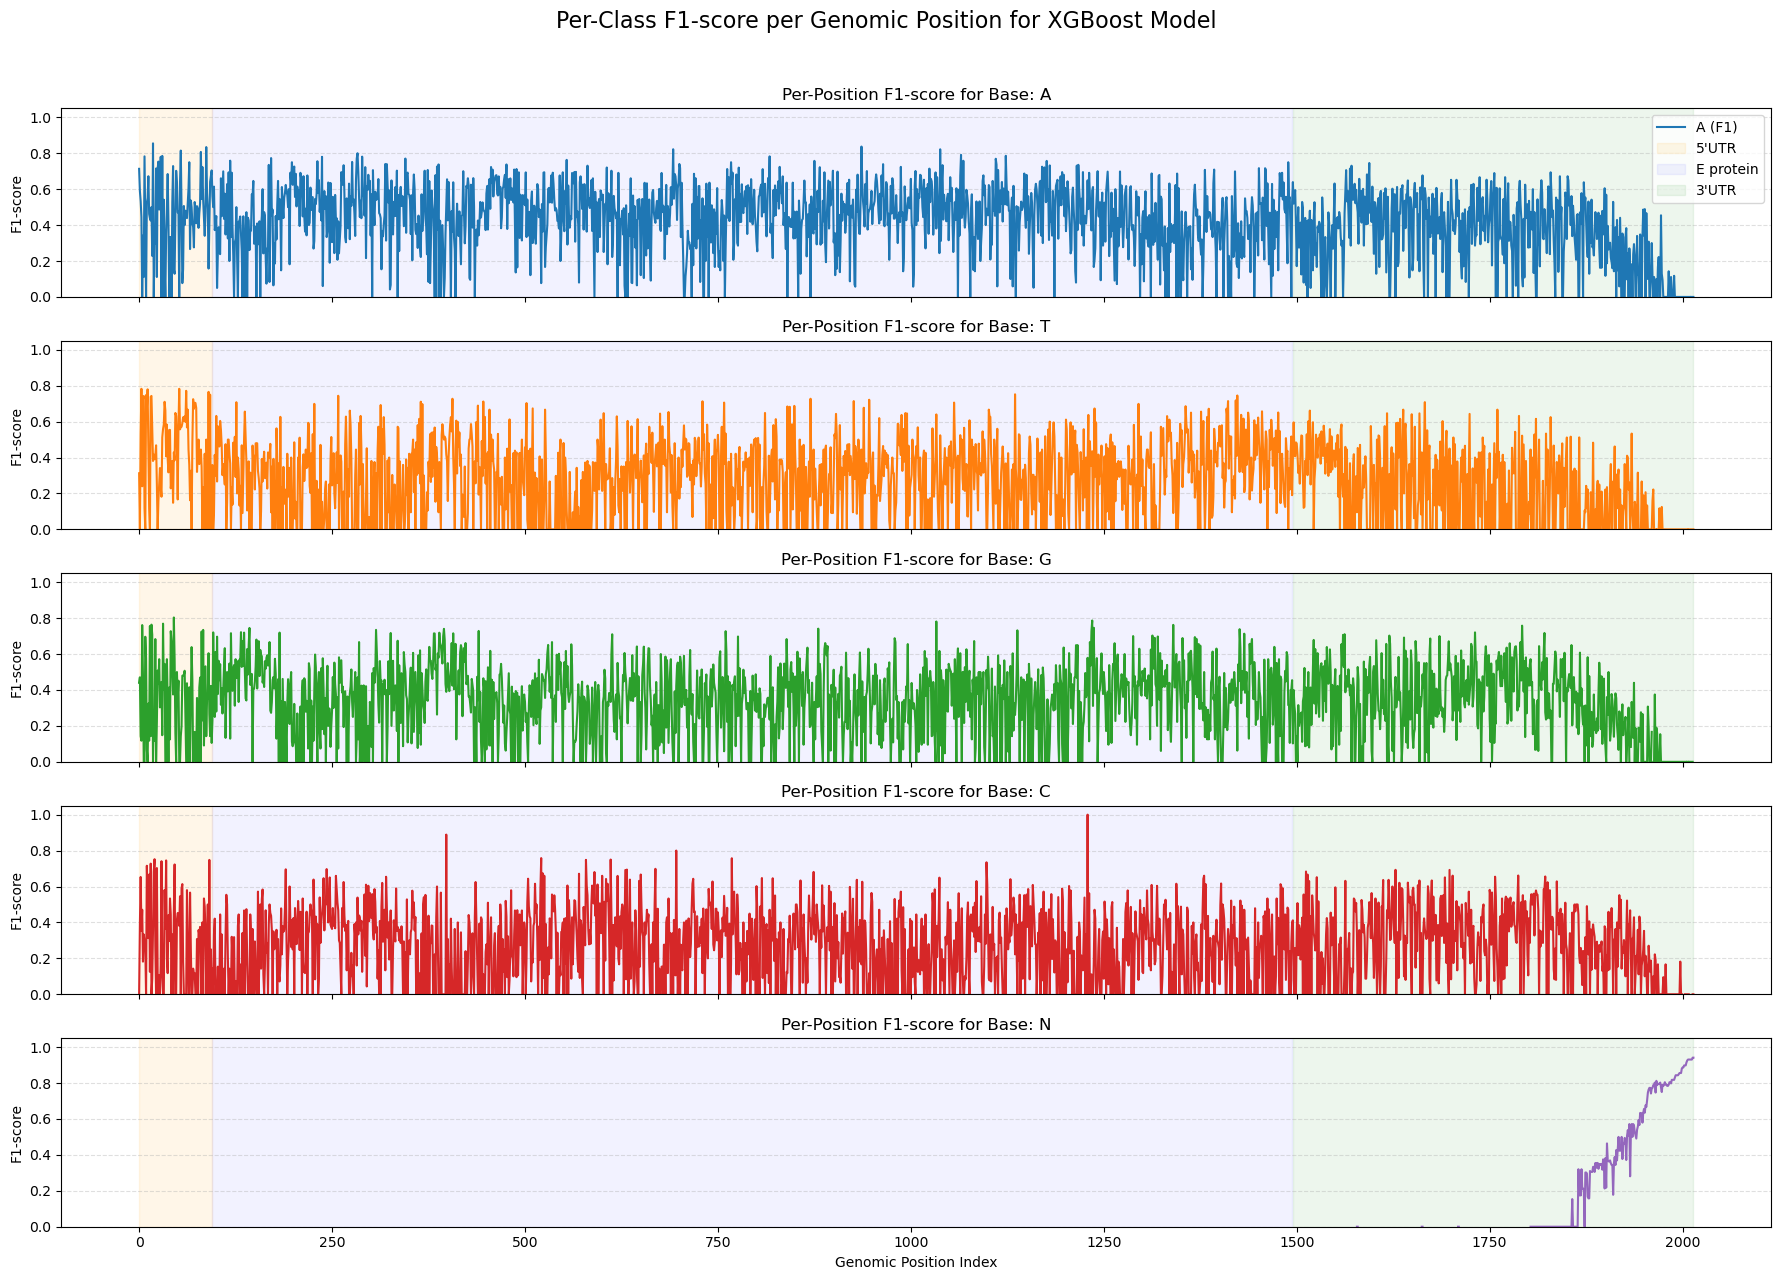

In [22]:
class_labels = {
    '1': 'A',
    '2': 'T',
    '3': 'G',
    '4': 'C',
    '0': 'N'
}
class_keys = ['1','2','3','4','0']
f1_matrix = report_df[[f'f1_{key}' for key in class_keys]].values

n_classes = len(class_keys)
fig, axes = plt.subplots(n_classes, 1, figsize=(18, 2.5 * n_classes), sharex=True, sharey=True)

for idx, key in enumerate(class_keys):
    ax = axes[idx]
    ax.plot(range(len(report_df)), f1_matrix[:, idx], label=f"{class_labels[key]} (F1)", color='C'+str(idx))
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-Position F1-score for Base: {class_labels[key]}")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax.axvspan(utr5_start, utr5_end, color='orange', alpha=0.09, label="5'UTR" if idx==0 else None)
    ax.axvspan(e_start, e_end, color='blue', alpha=0.05, label="E protein" if idx==0 else None)
    ax.axvspan(utr3_start, utr3_end, color='green', alpha=0.07, label="3'UTR" if idx==0 else None)
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Genomic Position Index")
plt.suptitle("Per-Class F1-score per Genomic Position for XGBoost Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analysis of Per-Class F1-score per Genomic Position for XGBoost Model

The above figure presents the per-position F1-score for each nucleotide base (A, T, G, C, N) across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome, as predicted by the XGBoost model. Each subplot corresponds to a distinct nucleotide class, with colored backgrounds marking the three main genomic regions.

#### Key Insights:

- **High and consistent F1-scores for major bases:**  
  The F1-scores for the four primary nucleotides (A, T, G, C) are consistently high across most genomic positions, often exceeding 0.4–0.5. This indicates that XGBoost is highly effective at correctly classifying individual bases from environmental predictors, with particularly robust performance for the most common nucleotides.

- **Base-specific variation and reliability:**  
  While overall performance is strong, some local variability is observed in the F1-scores for each base. Occasional dips may correspond to positions with rare nucleotides, class imbalance, or sites of high biological variability. Nonetheless, the model maintains relatively stable performance even in these challenging regions.

- **'N' base artifact:**  
  The F1-score for the 'N' (padding/unknown) base remains near zero for most of the genome, except for the terminal region of the 3′UTR, where it rises sharply. This reflects technical padding due to sequence length normalization rather than genuine model learning.

- **Consistency across genomic regions:**  
  The model’s strong F1 performance is observed throughout the 5′UTR, E protein, and 3′UTR regions, indicating that XGBoost’s predictive accuracy is not confined to specific genomic segments but is robust genome-wide.

#### Heatmap for Confusion Matrix

In [23]:
# Merge to associate macro_f1 with each confusion matrix
merged_df = pd.merge(report_df[['position', 'macro_f1']], conf_matrix_df, on='position')

base_labels = ['N', 'A', 'T', 'G', 'C']

def plot_conf_matrices_grid(df, positions, base_labels, fig_title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for idx, pos in enumerate(positions):
        cm = np.array(df[df['position'] == pos]['confusion_matrix'].values[0])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=base_labels, yticklabels=base_labels, 
                    ax=axes[idx], cbar=False)
        axes[idx].set_title(f"{pos}")
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')
    # Hide any unused subplots (if less than 10)
    for i in range(len(positions), 10):
        axes[i].axis('off')
    plt.suptitle(fig_title, fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

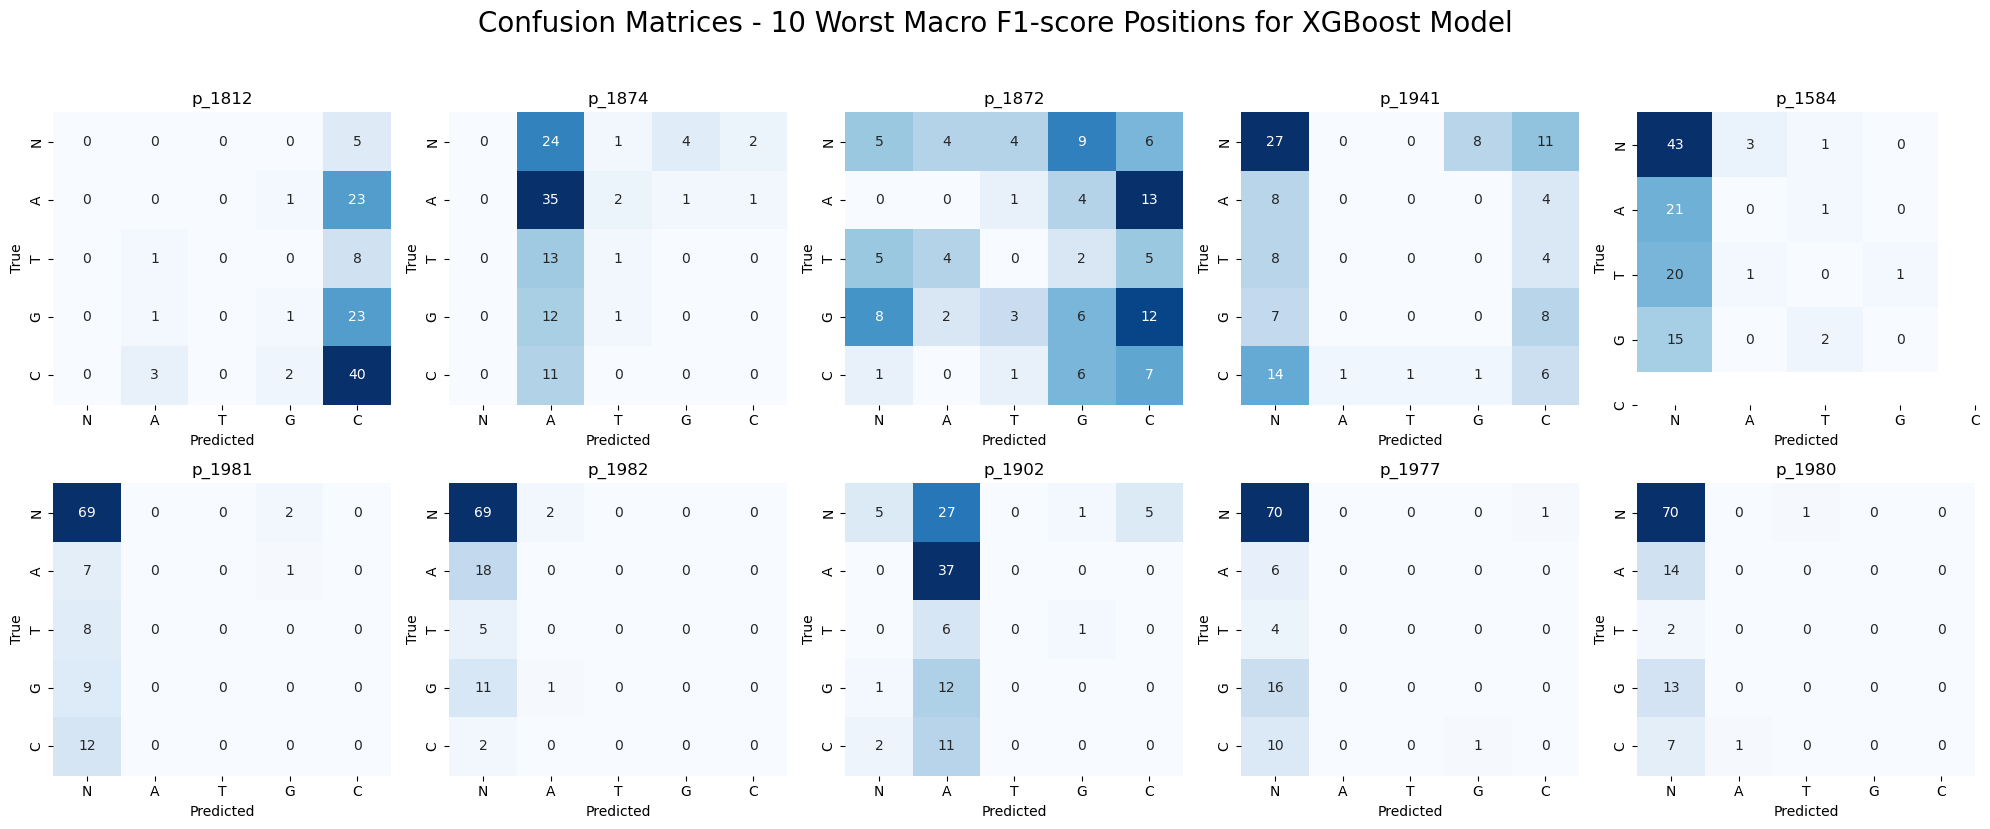

In [24]:
# 10 worst F1-score positions
worst_10 = merged_df.nsmallest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, worst_10, base_labels, "Confusion Matrices - 10 Worst Macro F1-score Positions for XGBoost Model")

### Analysis of Confusion Matrices — 10 Worst Macro F1-score Positions for XGBoost Model

The above figure presents confusion matrices for the 10 nucleotide positions with the lowest macro F1-scores in the XGBoost model. Each matrix summarizes the correspondence between true and predicted nucleotide classes (N, A, T, G, C) at a single genomic position, highlighting those sites where the model exhibited the greatest difficulty in prediction.

#### Key Insights:

- **Pronounced misclassification:**  
  At these poorly performing positions, the model shows a tendency to favor a particular nucleotide class or misclassify true nucleotides into neighboring classes. In several matrices, predictions are heavily skewed toward a single base (e.g., C or N), with many true labels incorrectly grouped under one prediction.

- **Limited correct predictions:**  
  The diagonal elements—which represent correct predictions—are sparsely populated, indicating a low rate of true positives for most nucleotide classes at these positions. This results in low macro F1-scores and highlights the challenge of accurate prediction at certain genomic sites.

- **Greater class confusion:**  
  Off-diagonal values (misclassifications) are prominent, especially in regions where biological variability or class imbalance is high. This suggests the model struggles to distinguish between bases that may have similar environmental determinants or are underrepresented in the training data.

- **Potential technical artifacts:**  
  For some positions (e.g., those in the 3′UTR), there is a skew toward the 'N' class, which may reflect sequence padding or low biological signal, rather than an inherent modeling limitation.

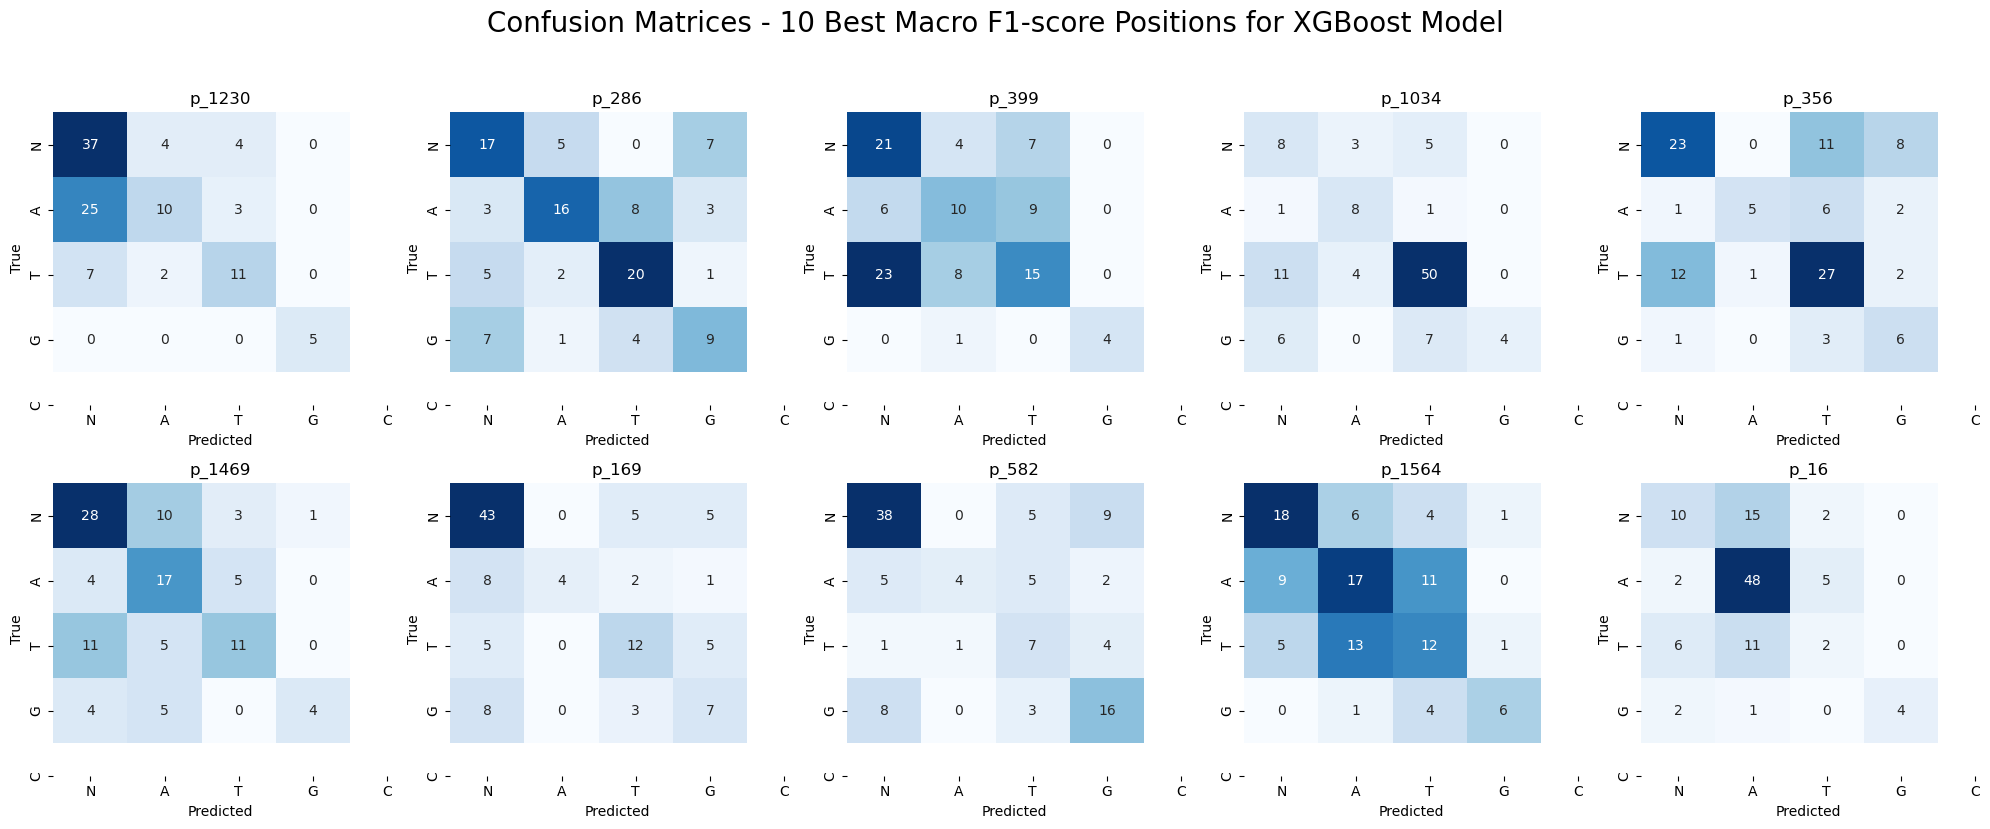

In [25]:
# 10 best F1-score positions
best_10 = merged_df.nlargest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, best_10, base_labels, "Confusion Matrices - 10 Best Macro F1-score Positions for XGBoost Model")

### Analysis of Confusion Matrices — 10 Best Macro F1-score Positions for XGBoost Model

The above figure presents confusion matrices for the 10 nucleotide positions with the highest macro F1-scores in the XGBoost model. Each matrix summarizes the correspondence between true and predicted nucleotide classes (N, A, T, G, C) at a single genomic position, highlighting the sites where the model exhibited the greatest predictive accuracy.

#### Key Insights:

- **High rate of correct predictions:**  
  These matrices are characterized by strong diagonal dominance, indicating that the majority of true nucleotides are correctly predicted across all classes. This pattern confirms the model’s robust performance and ability to accurately forecast nucleotide identity from environmental variables at these specific positions.

- **Balanced multi-class discrimination:**  
  For the best-performing positions, XGBoost successfully distinguishes among all major nucleotide classes (A, T, G, C), with minimal confusion between classes. This is particularly notable given the complexity of the multi-class, multi-output prediction task.

- **Low off-diagonal misclassification:**  
  Off-diagonal elements, which represent misclassifications, are infrequent and typically small in magnitude. This further supports the reliability and specificity of the model’s predictions for these positions.

- **Effective handling of conserved and variable sites:**  
  The model performs well both in regions likely to be highly conserved and in positions exhibiting greater sequence diversity, demonstrating adaptability to a range of genomic contexts.

- **Comparative context:**  
  Compared to worst-performing positions, these confusion matrices illustrate the upper bound of the model’s capability. The high macro F1-scores at these sites reinforce the suitability of XGBoost for environment-based nucleotide prediction, particularly at genomic positions where environmental variables are strongly associated with sequence variation.

In [26]:
# Save to CSV (or JSON for confusion matrices)
report_df.to_csv('../results/xgb_per_position_classification_report.csv', index=False)
conf_matrix_df.to_json('../results/xgb_per_position_confusion_matrices.json', orient='records')

### Save the model

In [27]:
joblib.dump(xgb_multi, '../models/xgb_multioutput_model.joblib')

['../models/xgb_multioutput_model.joblib']